In [2]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [3]:
with open('Deterministic_results_with_start.json') as json_file:
    F_results = json.load(json_file)


In [4]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [5]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


         Antigen  Year  Value
0          Mumps     9    0.0
1    Hepatitis_B     2    0.0
2          Polio     7    0.0
3            Hib     1    0.0
4        Tetanus     3    0.0
..           ...   ...    ...
127      Rubella     1    0.0
128        Polio     4    0.0
129        Mumps     1    0.0
130      Rubella     8    0.0
131          HPV     6    0.0

[132 rows x 3 columns]


In [6]:
import pandas as pd

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Grouping and counting
result = df.groupby(['Antigen', 'Year'])['Value'].sum().reset_index()
# result = result[result['Value'] != 0.0]

# Grouping by Antigen and summing the Value column
# result = df.groupby('Antigen')['Value'].sum().reset_index()

# Displaying the result
print(result)


        Antigen  Year  Value
0    Diphtheria     0    0.0
1    Diphtheria     1    0.0
2    Diphtheria     2    0.0
3    Diphtheria     3    0.0
4    Diphtheria     4    0.0
..          ...   ...    ...
127     Tetanus     6    0.0
128     Tetanus     7    0.0
129     Tetanus     8    0.0
130     Tetanus     9    0.0
131     Tetanus    10    0.0

[132 rows x 3 columns]


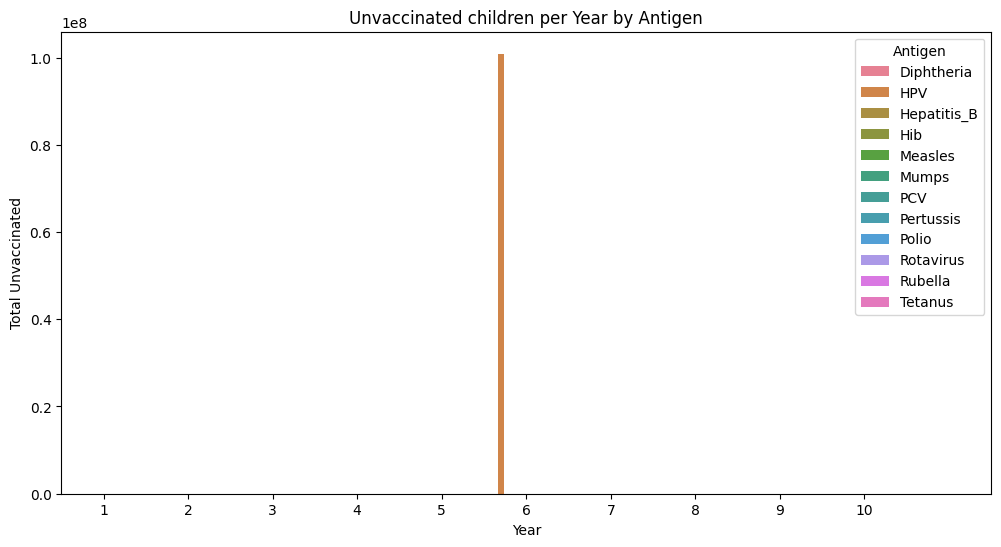

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.show()


## Tender Schedule without starting point

In [12]:
with open('Deterministic_results.json') as json_file:
    Q_results_clean = json.load(json_file)

In [13]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in Q_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

In [16]:
grouped_results

{'S[': [{'S[Tetanus,6]': 0.0},
  {'S[HPV,2]': 0.0},
  {'S[Pertussis,0]': 0.0},
  {'S[HPV,5]': 0.0},
  {'S[Diphtheria,3]': 0.0},
  {'S[Hib,10]': 0.0},
  {'S[HPV,7]': 0.0},
  {'S[Polio,5]': 0.0},
  {'S[PCV,9]': 0.0},
  {'S[Hib,7]': 0.0},
  {'S[HPV,9]': 0.0},
  {'S[Polio,6]': 0.0},
  {'S[Rotavirus,4]': 0.0},
  {'S[Polio,3]': 0.0},
  {'S[Polio,0]': 0.0},
  {'S[Pertussis,4]': 0.0},
  {'S[Pertussis,7]': 0.0},
  {'S[Pertussis,2]': 0.0},
  {'S[Hib,6]': 0.0},
  {'S[PCV,6]': 0.0},
  {'S[Rubella,4]': 0.0},
  {'S[Rotavirus,9]': 0.0},
  {'S[Diphtheria,7]': 0.0},
  {'S[Mumps,0]': 0.0},
  {'S[Tetanus,9]': 0.0},
  {'S[Measles,2]': 0.0},
  {'S[Tetanus,5]': 0.0},
  {'S[Pertussis,10]': 0.0},
  {'S[Measles,10]': 0.0},
  {'S[Pertussis,3]': 0.0},
  {'S[HPV,10]': 0.0},
  {'S[Pertussis,5]': 0.0},
  {'S[Rotavirus,8]': 0.0},
  {'S[Pertussis,1]': 0.0},
  {'S[Hepatitis_B,4]': 0.0},
  {'S[Hepatitis_B,5]': 0.0},
  {'S[PCV,8]': 0.0},
  {'S[Measles,4]': 0.0},
  {'S[PCV,5]': 0.0},
  {'S[HPV,4]': 0.0},
  {'S[Rubella,2]

In [14]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


        Antigen  Year  Value
0       Tetanus     6    0.0
1           HPV     2    0.0
2     Pertussis     0    0.0
3           HPV     5    0.0
4    Diphtheria     3    0.0
..          ...   ...    ...
127       Mumps     3    0.0
128     Measles     9    0.0
129  Diphtheria     0    0.0
130         Hib     0    0.0
131         PCV     2    0.0

[132 rows x 3 columns]


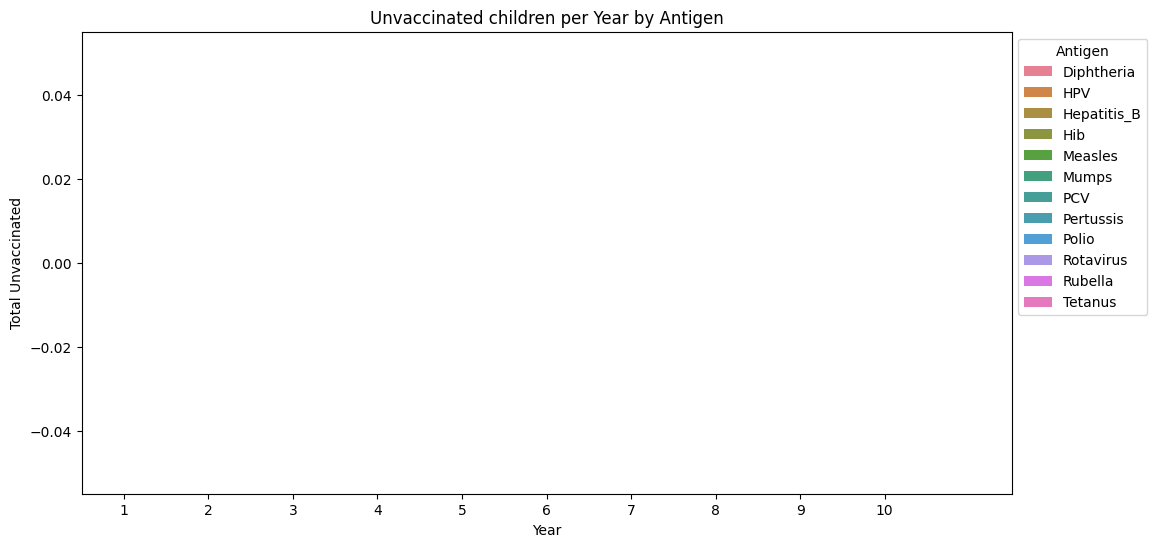

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.show()
